<a href="https://colab.research.google.com/github/dongukl/dongukl-robot_danger_detection/blob/main/03_gradcam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle -q
!apt-get install -y fonts-nanum -qq

Selecting previously unselected package fonts-nanum.
(Reading database ... 122412 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader

In [3]:

# 나눔 폰트 경로 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

# matplotlib 전역 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("한글 폰트 설정 완료!")

한글 폰트 설정 완료!


In [4]:
from google.colab import files
files.upload()

# 인증 파일 위치 설정
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle 연결 완료!")

Saving kaggle.json to kaggle.json
Kaggle 연결 완료!


In [5]:
# 다운로드
!wget "http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz" \
     -O /content/UCSD.tar.gz \
     --progress=bar:force 2>&1

--2026-05-17 06:05:34--  http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz
Resolving www.svcl.ucsd.edu (www.svcl.ucsd.edu)... 169.228.63.130
Connecting to www.svcl.ucsd.edu (www.svcl.ucsd.edu)|169.228.63.130|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 740306953 (706M) [application/x-gzip]
Saving to: ‘/content/UCSD.tar.gz’

/content/UCSD.tar.g 100%[===================>] 706.01M  18.4MB/s    in 40s     

2026-05-17 06:06:15 (17.5 MB/s) - ‘/content/UCSD.tar.gz’ saved [740306953/740306953]



In [6]:
!mkdir -p /content/data
!tar -xzf /content/UCSD.tar.gz -C /content/data
print("압축 해제 완료!")

압축 해제 완료!


In [7]:
# 폴더 구조 확인
# os.walk = 특정 경로 내에 존재하는 폴더(디렉토리)와 파일 리스트 뿐만 아니라, 모든 하위 디렉토리 구조를 다 검색
for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    if level > 3:
        continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 3:
        # 파일 3개만 미리보기
        for f in sorted(files)[:3]:
            print(f'{indent}  {f}')

data/
  UCSD_Anomaly_Dataset.v1p2/
    UCSDped1/
      Test/
        .DS_Store
        ._UCSDped1.m
        UCSDped1.m
      Train/
        .DS_Store
        ._.DS_Store
    UCSDped2/
      Test/
        .DS_Store
        ._.DS_Store
        ._UCSDped2.m
      Train/
        .DS_Store
        ._.DS_Store


총 훈련 프레임 수: 2550


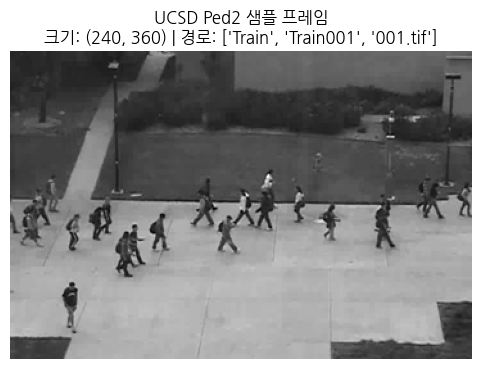

In [8]:
# 샘플 이미지 1장 확인
# Ped2 훈련 프레임 찾기
frames = sorted(glob.glob('/content/data/**/UCSDped2/Train/**/*.tif', recursive=True))
print(f"총 훈련 프레임 수: {len(frames)}")

# 첫 번째 프레임 시각화
img = cv2.imread(frames[0], cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(6, 4))
plt.imshow(img, cmap='gray')
plt.title(f'UCSD Ped2 샘플 프레임\n크기: {img.shape} | 경로: {frames[0].split("/")[-3:]}')
plt.axis('off')
plt.show()

In [9]:
BASE_PATH = '/content/data/UCSD_Anomaly_Dataset.v1p2/UCSDped1'
TRAIN_PATH = os.path.join(BASE_PATH, 'Train')
TEST_PATH = os.path.join(BASE_PATH, 'Test')

IMG_SIZE = (224, 224)

print(f'훈련 경로 : {TRAIN_PATH}')
print(f'테스트 경로 : {TEST_PATH}')
print(f'이미지 크기 : {IMG_SIZE}')

훈련 경로 : /content/data/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Train
테스트 경로 : /content/data/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test
이미지 크기 : (224, 224)


In [10]:
def load_frame(folder_path):
    # glob: 파일명을 리스트 형식으로 반환
    frame_paths = sorted(glob.glob(os.path.join(folder_path, '*.tif')))

    if len(frame_paths) == 0:
        return []
    frames = []
    for path in frame_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE)
        frames.append(img)
    return frames

train_folders = sorted(glob.glob(os.path.join(TRAIN_PATH, 'Train*')))
sample_frames = load_frame(train_folders[0])

print(f"훈련 영상 폴더 수 : {len(train_folders)}")
print(f"첫 번째 영상 프레임 수 : {len(sample_frames)}")
print(f"프레임 크기: {sample_frames[0].shape}")

훈련 영상 폴더 수 : 34
첫 번째 영상 프레임 수 : 200
프레임 크기: (224, 224)


In [11]:
def compute_optical_flow(frame1, frame2):
    flow = cv2.calcOpticalFlowFarneback(
        frame1, frame2,
        None,
        pyr_scale=0.5,
        levels=3,
        winsize=15,
        iterations=3,
        poly_n=5,
        poly_sigma=1.2,
        flags=0
    )

    dx, dy = flow[..., 0], flow[..., 1]
    magnitude = np.sqrt(dx**2 + dy**2)
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    magnitude = magnitude.astype(np.uint8)

    return magnitude

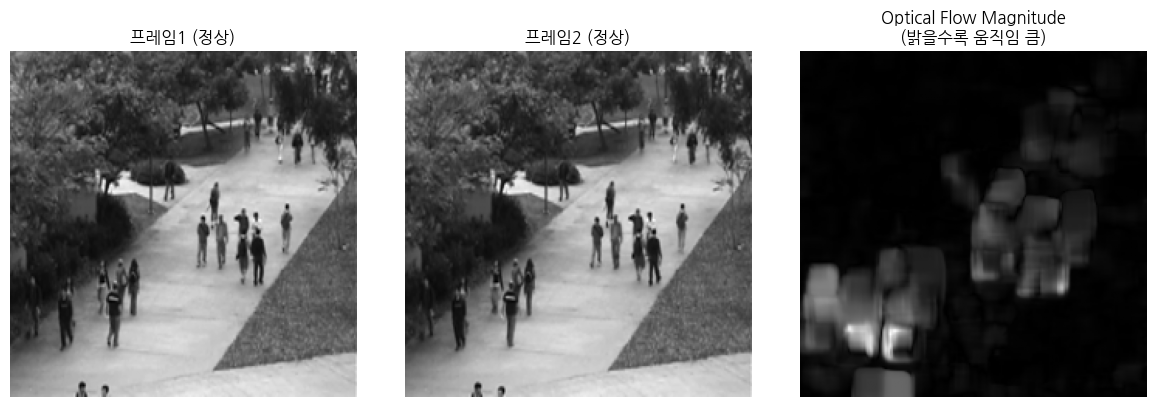

Flow map 크기: (224, 224)
Flow 최솟값: 0 최댓값: 255


In [12]:
# 테스트
frame1 = sample_frames[0]
frame2 = sample_frames[1]
flow_map = compute_optical_flow(frame1, frame2)

fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(frame1, cmap='gray')
axes[0].set_title('프레임1 (정상)')
axes[0].axis('off')

axes[1].imshow(frame2, cmap='gray')
axes[1].set_title('프레임2 (정상)')
axes[1].axis('off')


axes[2].imshow(flow_map, cmap='gray')
axes[2].set_title('Optical Flow Magnitude\n(밝을수록 움직임 큼)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'Flow map 크기: {flow_map.shape}')
print(f'Flow 최솟값: {flow_map.min()} 최댓값: {flow_map.max()}')



In [13]:
def build_dataset(train_path, test_path):
    flow_map = []
    labels = []

    train_folders = sorted(glob.glob(os.path.join(train_path, 'Train*')))
    print(f"훈련 영상 처리중... ({len(train_folders)}개)")
    for folder in train_folders:
        frames = load_frame(folder)
        for i in range(len(frames) - 1):
            flow = compute_optical_flow(frames[i], frames[i+1])
            flow_map.append(flow)
            labels.append(0)
    test_folders = sorted([
        f for f in glob.glob(os.path.join(test_path, 'Test*'))
        if '_gt' not in f
    ])
    print(f"테스트 영상 처리중...({len(test_folders)}개)")

    for folder in test_folders:
        frames = load_frame(folder)
        gt_folder = folder + '_gt'
        label = 1 if os.path.exists(gt_folder) else 0
        for i in range(len(frames) - 1):
            flow = compute_optical_flow(frames[i], frames[i+1])
            flow_map.append(flow)
            labels.append(label)

    return np.array(flow_map), np.array(labels)

flow_maps, labels = build_dataset(TRAIN_PATH, TEST_PATH)

print(f"\n전처리 완료")
print(f"전체 샘플 수 : {len(flow_maps)}")
print(f"정상(0): {np.sum(labels == 0)}개")
print(f"이상(1): {np.sum(labels == 1)}개")
print(f"shape: {flow_maps.shape}")


훈련 영상 처리중... (34개)
테스트 영상 처리중...(36개)

전처리 완료
전체 샘플 수 : 13930
정상(0): 11940개
이상(1): 1990개
shape: (13930, 224, 224)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    flow_maps, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"훈련데이터 : {len(X_train)} | 정상 : {sum(y_train == 0)} | 이상 : {sum(y_train == 1)}")
print(f"검증데이터 : {len(X_val)} | 정상 : {sum(y_val == 0)} | 이상 : {sum(y_val == 1)}")
print(f"테스트데이터 : {len(X_test)} | 정상 : {sum(y_test == 0)} | 이상 : {sum(y_test == 1)}")


훈련데이터 : 8915 | 정상 : 7641 | 이상 : 1274
검증데이터 : 2229 | 정상 : 1911 | 이상 : 318
테스트데이터 : 2786 | 정상 : 2388 | 이상 : 398


In [15]:
class FlowDataset(Dataset):
    def __init__(self, flow_maps, labels):
        self.images = torch.FloatTensor(flow_maps).unsqueeze(1) / 255.0
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


train_dataset = FlowDataset(X_train, y_train)
val_dataset = FlowDataset(X_val, y_val)
test_dataset = FlowDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"훈련 데이터 로더 : {len(train_loader)}")
print(f"검증 데이터 로더 : {len(val_loader)}")
print(f"테스트 데이터 로더 : {len(test_loader)}")

images, labels_batch = next(iter(train_loader))
print(f"배치 이미지 크기 : {images.shape}")
print(f"배치 라벨 크기 : {labels_batch.shape}")

훈련 데이터 로더 : 279
검증 데이터 로더 : 70
테스트 데이터 로더 : 88
배치 이미지 크기 : torch.Size([32, 1, 224, 224])
배치 라벨 크기 : torch.Size([32])


In [16]:
# 라이브러리 임포트
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

사용 장치: cuda


In [19]:
# 모델 불러오기 (구글 드라이브에서)
from google.colab import drive
drive.mount('/content/drive')

def build_model():
    model = models.resnet18(pretrained=False)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.conv1.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model.to(device)

# 저장된 최고 모델 로드
model = build_model()
model.load_state_dict(
    torch.load('/content/drive/MyDrive/project/scene-risk-perception/best_model.pth',
               map_location=device)
)
model.eval()
print("모델 로드 완료!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
모델 로드 완료!


In [21]:
# Grad-CAM 클래스
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # 타겟 레이어에 훅 등록
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor, class_idx=None):
        # 순전파
        output = self.model(image_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # 역전파
        self.model.zero_grad()
        output[0, class_idx].backward()

        # 가중치 계산 (GAP)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        # 가중합 + ReLU
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        # 정규화
        cam = cam.squeeze().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, class_idx

# Grad-CAM 초기화 (layer4 마지막 블록 타겟)
gradcam = GradCAM(model, model.layer4[-1])
print("Grad-CAM 초기화 완료!")

Grad-CAM 초기화 완료!


In [33]:
# 셀 4 - 시각화 함수
def visualize_gradcam(image_tensor, cam, label, pred, ax_row):
    """
    1행: 원본 Optical Flow 이미지
    2행: Grad-CAM 히트맵
    3행: 오버레이
    """
    img = image_tensor.squeeze().cpu().numpy()

    # 히트맵 컬러 변환
    heatmap = cv2.applyColorMap(
        np.uint8(255 * cam), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본을 3채널로 변환 (오버레이용)
    img_3ch = np.stack([img * 255] * 3, axis=-1).astype(np.uint8)

    # 오버레이
    overlay = cv2.addWeighted(img_3ch, 0.5, heatmap, 0.5, 0)

    label_str = "이상(위험)" if label == 1 else "정상"
    pred_str  = "이상(위험)" if pred  == 1 else "정상"
    correct   = "O" if label == pred else "X"

    ax_row[0].imshow(img, cmap='gray')
    ax_row[0].set_title(f'Optical Flow\n실제: {label_str}')
    ax_row[0].axis('off')

    ax_row[1].imshow(cam, cmap='jet')
    ax_row[1].set_title(f'Grad-CAM 히트맵\n예측: {pred_str} {correct}')
    ax_row[1].axis('off')

    ax_row[2].imshow(overlay)
    ax_row[2].set_title('오버레이\n(빨간=모델이 집중한 영역)')
    ax_row[2].axis('off')

In [34]:
# 정상/이상 각각 4개씩 시각화
model.eval()

normal_samples  = []  # 정상 샘플
anomaly_samples = []  # 이상 샘플

# 테스트셋에서 정상/이상 각 4개 수집
for images, labels_batch in test_loader:
    for img, lbl in zip(images, labels_batch):
        if lbl.item() == 0 and len(normal_samples) < 4:
            normal_samples.append((img, lbl.item()))
        elif lbl.item() == 1 and len(anomaly_samples) < 4:
            anomaly_samples.append((img, lbl.item()))
        if len(normal_samples) == 4 and len(anomaly_samples) == 4:
            break
    if len(normal_samples) == 4 and len(anomaly_samples) == 4:
        break

print(f"정상 샘플: {len(normal_samples)}개")
print(f"이상 샘플: {len(anomaly_samples)}개")

정상 샘플: 4개
이상 샘플: 4개


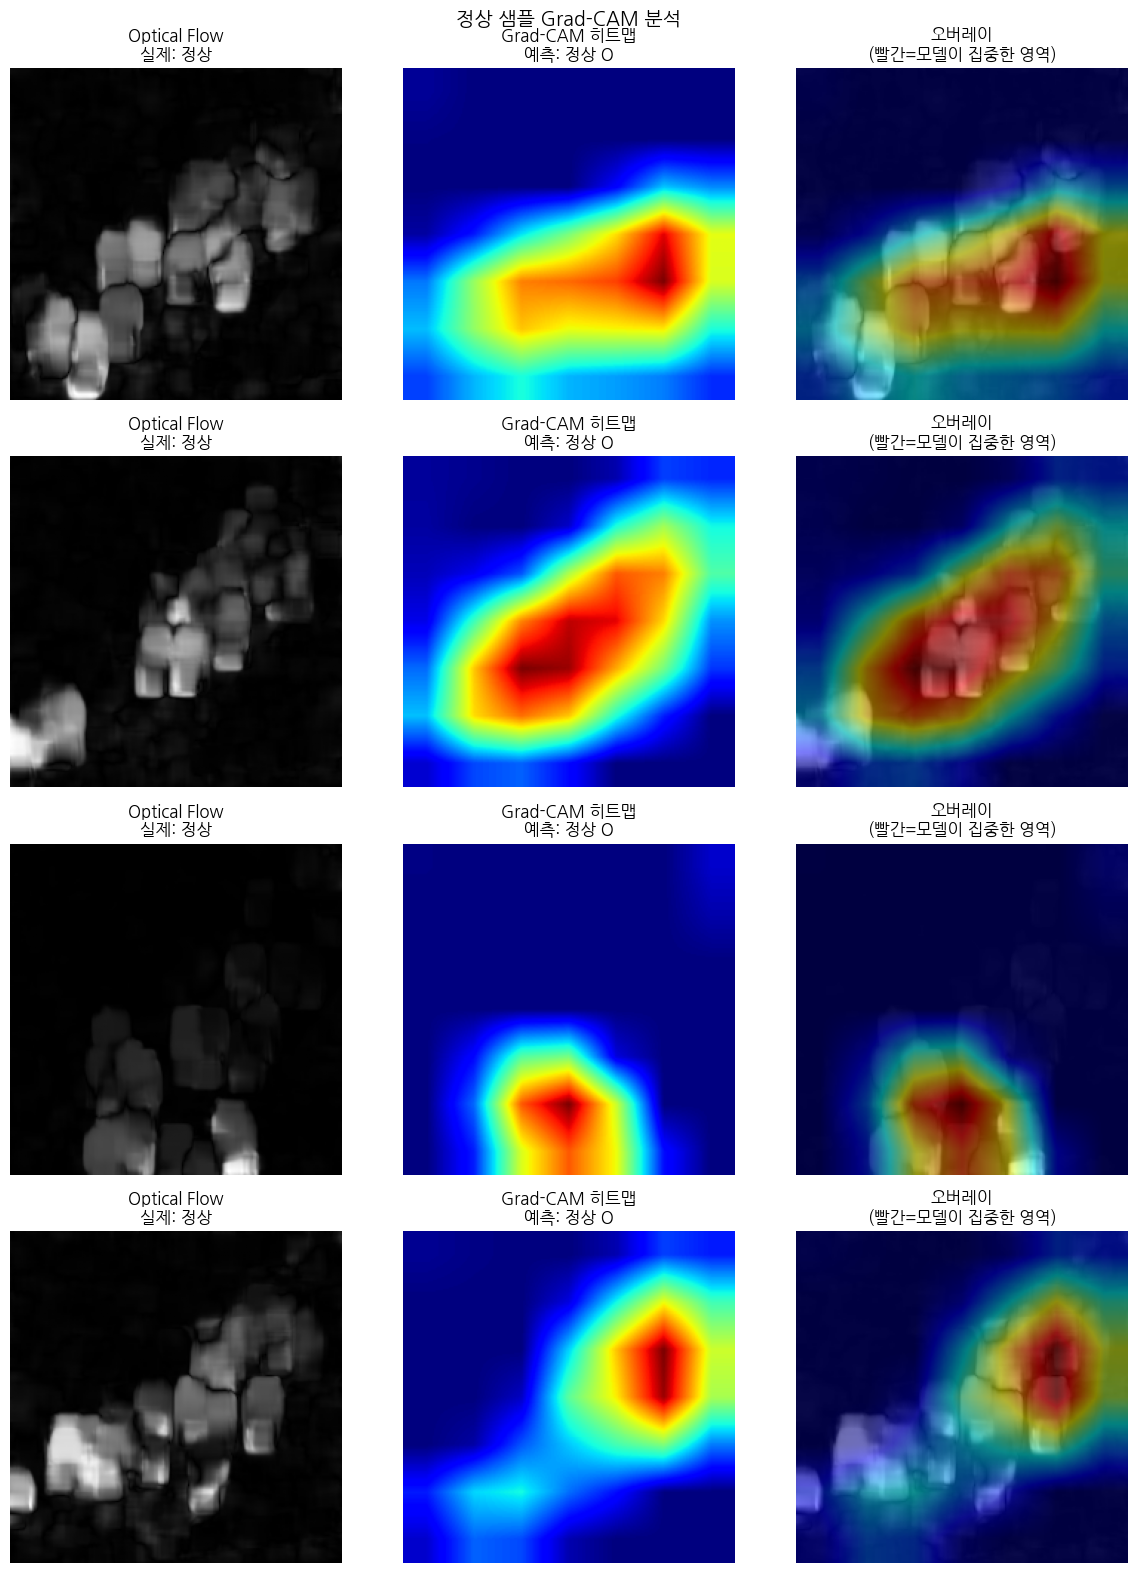

정상 샘플 시각화 완료!


In [35]:
# 정상 샘플 Grad-CAM 시각화
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('정상 샘플 Grad-CAM 분석', fontsize=14, fontweight='bold')

for i, (img, lbl) in enumerate(normal_samples):
    img_tensor = img.unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)

    with torch.enable_grad():
        cam, pred = gradcam.generate(img_tensor)

    visualize_gradcam(img, cam, lbl, pred, axes[i])

plt.tight_layout()
plt.savefig('/content/gradcam_normal.png', dpi=150, bbox_inches='tight')
plt.show()
print("정상 샘플 시각화 완료!")

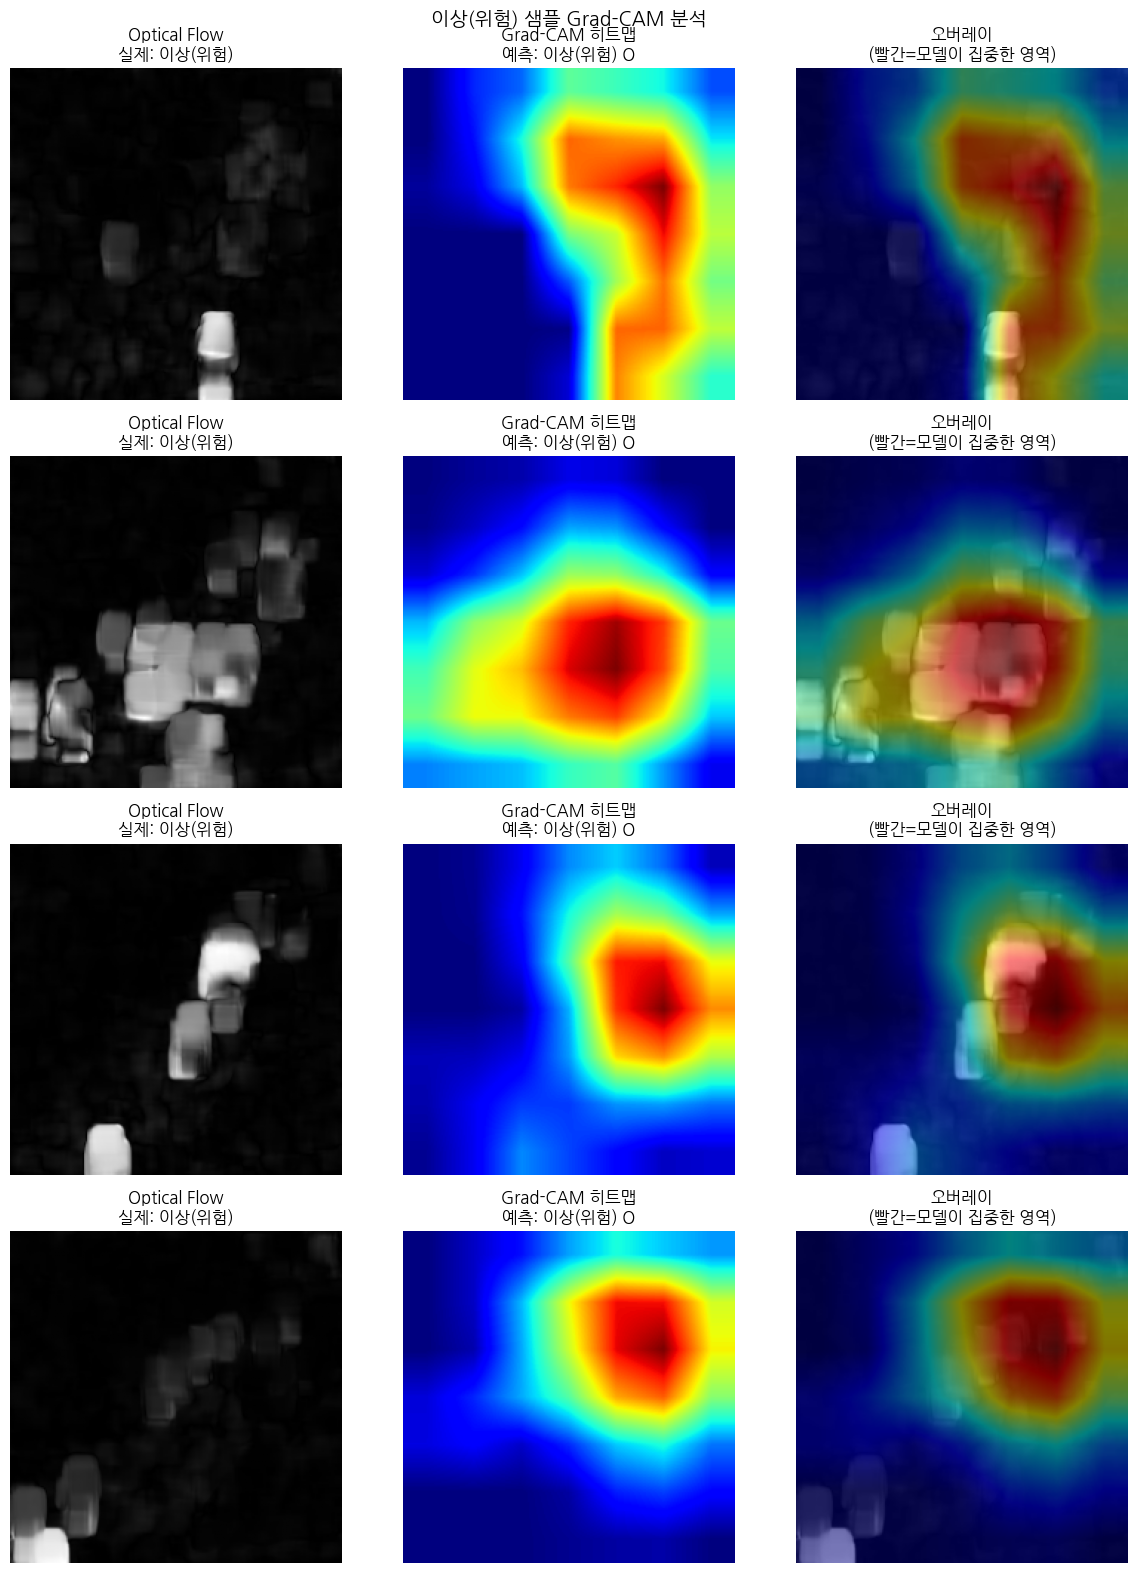

이상 샘플 시각화 완료!


In [36]:
# 이상 샘플 Grad-CAM 시각화
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('이상(위험) 샘플 Grad-CAM 분석', fontsize=14, fontweight='bold')

for i, (img, lbl) in enumerate(anomaly_samples):
    img_tensor = img.unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)

    with torch.enable_grad():
        cam, pred = gradcam.generate(img_tensor)

    visualize_gradcam(img, cam, lbl, pred, axes[i])

plt.tight_layout()
plt.savefig('/content/gradcam_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print("이상 샘플 시각화 완료!")

False Negative 샘플: 4개


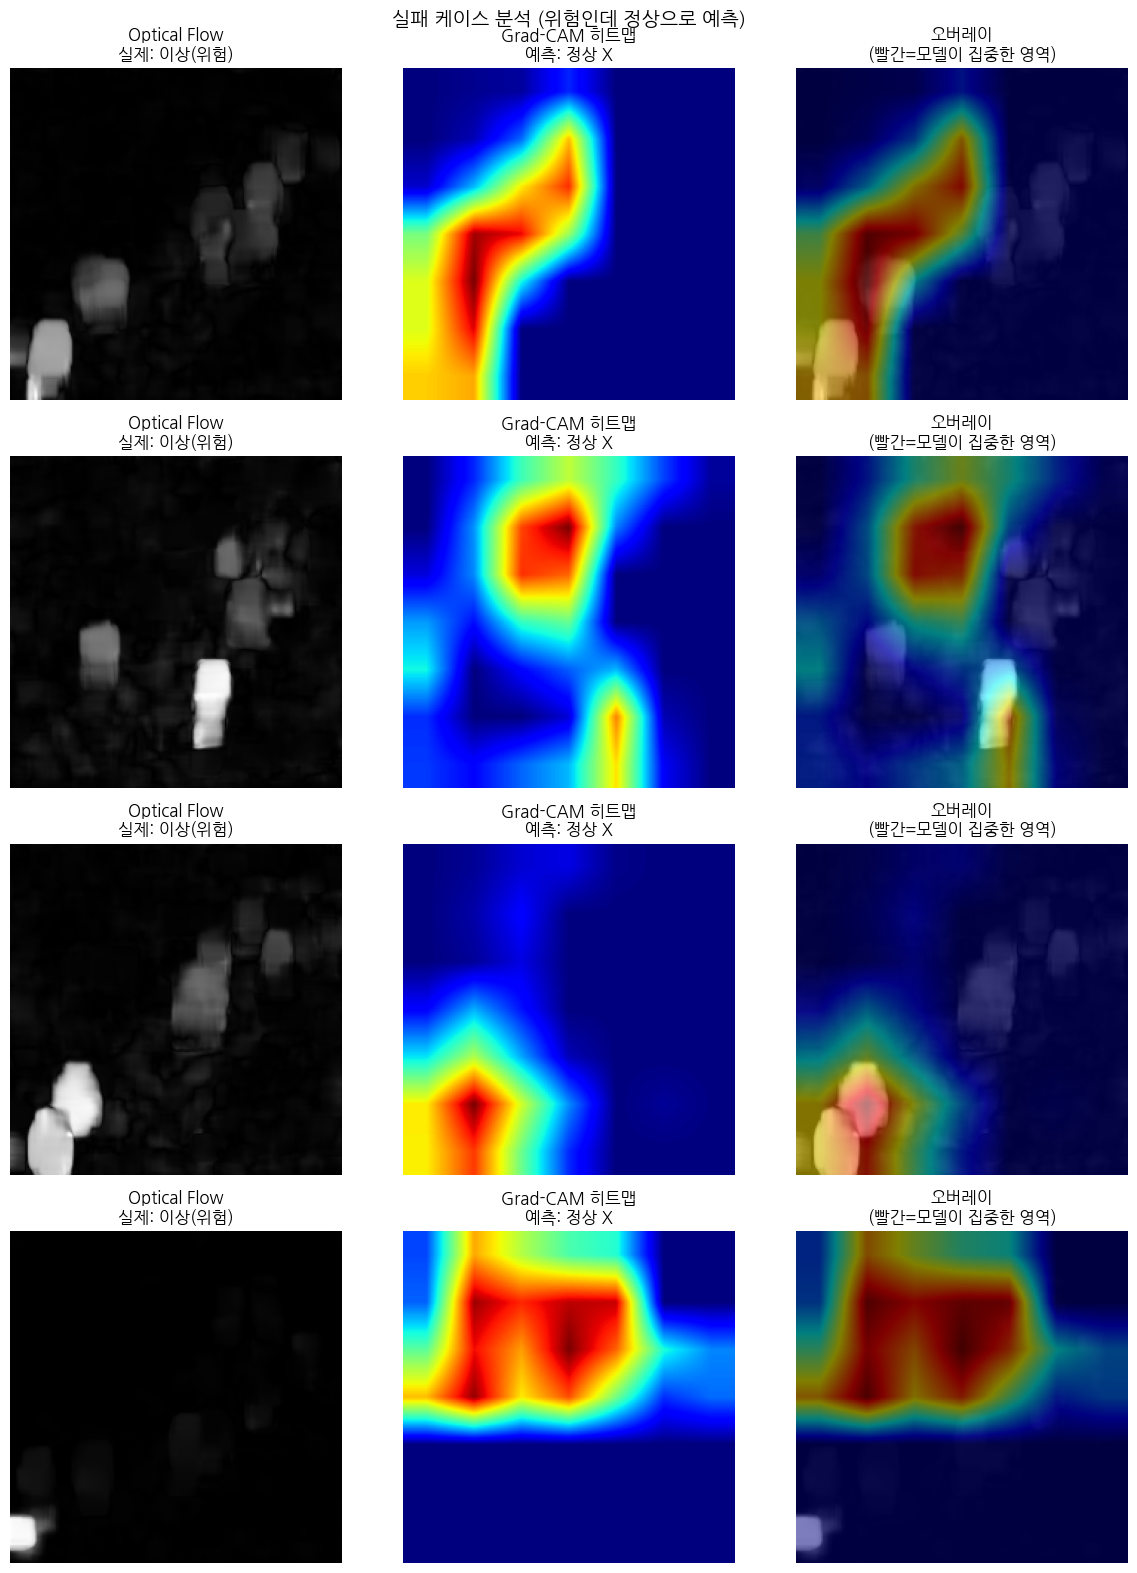

In [37]:
# 셀 8 - 실패 케이스 분석 (False Negative: 위험인데 정상으로 예측)
fn_samples = []  # False Negative

for images, labels_batch in test_loader:
    for img, lbl in zip(images, labels_batch):
        img_tensor = img.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(img_tensor)
            pred = output.argmax(dim=1).item()

        # 실제 이상인데 정상으로 예측한 케이스
        if lbl.item() == 1 and pred == 0:
            fn_samples.append((img, lbl.item(), pred))

        if len(fn_samples) == 4:
            break
    if len(fn_samples) == 4:
        break

print(f"False Negative 샘플: {len(fn_samples)}개")

if len(fn_samples) > 0:
    fig, axes = plt.subplots(len(fn_samples), 3, figsize=(12, len(fn_samples)*4))
    if len(fn_samples) == 1:
        axes = axes.reshape(1, -1)
    fig.suptitle('실패 케이스 분석 (위험인데 정상으로 예측)', fontsize=14)

    for i, (img, lbl, pred) in enumerate(fn_samples):
        img_tensor = img.unsqueeze(0).to(device)
        img_tensor.requires_grad_(True)
        with torch.enable_grad():
            cam, _ = gradcam.generate(img_tensor, class_idx=1)
        visualize_gradcam(img, cam, lbl, pred, axes[i])

    plt.tight_layout()
    plt.savefig('/content/gradcam_failures.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("False Negative 없음! 모든 위험 샘플을 정확히 감지했습니다.")

In [38]:
# 이미지가 /content/에 저장됐는지 확인
import os
print(os.path.exists('/content/gradcam_anomaly.png'))
print(os.path.exists('/content/gradcam_failures.png'))

True
True


In [40]:
import shutil
shutil.copy('/content/gradcam_anomaly.png',
            '/content/drive/MyDrive/project/scene-risk-perception/gradcam_anomaly.png')
shutil.copy('/content/gradcam_failures.png',
            '/content/drive/MyDrive/project/scene-risk-perception/gradcam_failures.png')
print("드라이브 백업 완료!")

드라이브 백업 완료!
